# Food Delivery Time Prediction

## Data Preprocessing

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Importing the dataset

In [2]:
dataset = pd.read_csv('Food_Delivery_Time_Prediction.csv')

X = dataset.iloc[:, 1:-1].values

y = dataset.iloc[:, -1].values

In [3]:
print(X[0])
print(f"shape:{X.shape}")

[8 'Tuesday' 'Clear' 'CBD' 'Commercial' 'Scooter' 3.1 3.8 3.8 'Pizza' 1
 'Medium' 23 30.55 'Moderate' 15 28.7]
shape:(50000, 17)


In [4]:
print(y)
print(f"shape:{y.shape}")

[ 91  21  52 ...  66  92 103]
shape:(50000,)


### Encoding categorical data

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer([('encoder', OneHotEncoder(drop = 'first'), [1,2,3,4,5,9,11,14])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [6]:
print(X[0])
print(f"shape:{X.shape}")

[0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0
 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 1.0 0.0 1.0 0.0 8 3.1 3.8
 3.8 1 23 30.55 15 28.7]
shape:(50000, 43)


Note: 8 dummies dropped(alphabetically first level of each column - done explicitly, not relying on sklearn to handle):

* Friday
* Clear
* CBD pickup
* CBD dropoff
* Bicycle
* Bakery
* High load
* High traffic

Now represented by ***b***.


### Splitting the dataset into the Training set and Test set

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 74)

## Train the Model - Multiple Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
regressor =  LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

### Predict Resluts

In [9]:
y_pred = regressor.predict(X_test)
np.set_printoptions(precision = 2)
print(np.concatenate(
                     (y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),
                      axis = 1
                      ))


[[ 74.21  77.  ]
 [158.73 180.  ]
 [ 79.22  73.  ]
 ...
 [ 78.8   70.  ]
 [109.04 105.  ]
 [ 95.3   83.  ]]


## Evaluate the Model

### R² and RMSE

In [10]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred)}")



R2 Score: 0.930322184489478
RMSE: 9.341809152497573


### Adjusted R²

In [11]:
def adjusted_r2 (r2, n, p):
  return 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"y_test and y_pred adjusted_r2: {adjusted_r2(r2_score(y_test, y_pred),X_test.shape[0], X_test.shape[1])}")
print(f"y_train and regressor.predict(X_train) adjusted_r2: {adjusted_r2(r2_score(y_train,regressor.predict(X_train)),X_train.shape[0], X_train.shape[1])}")



y_test and y_pred adjusted_r2: 0.9300212457523394
y_train and regressor.predict(X_train) adjusted_r2: 0.9318090001678866


### Backward Elimination

In [30]:
def backward_elimination(X, y, sl=0.05):
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = X.astype(float)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    print(f"Summary: {model.summary()}")
    print(f"p values: {model.pvalues}")

    enc_feature_names = ct.named_transformers_['encoder'].get_feature_names_out()
    numeric_names = [
        'Order_Hour',
        'Rider_Experience_Years',
        'Rider_Rating',
        'Restaurant_Rating',
        'Order_Items',
        'Preparation_Time_Min',
        'Road_Distance_km',
        'Number_of_Signals',
        'Average_Speed_kmph'
    ]

    names = ['const'] + list(enc_feature_names) + list(numeric_names)
    kept_idx = list(range(X.shape[1]))     # before the loop, alongside `names`



    dropped = []

    # VIF before
    for i in range(1, X.shape[1]):
        print(f"variance{names[i]} before: {variance_inflation_factor(X, i)}")

    # Backward elimination
    while True:
        model = sm.OLS(y, X).fit()

        worst = np.argmax(model.pvalues)

        if worst == 0 or model.pvalues[worst] <= sl:
            break

        feature = names[worst]
        p_value = model.pvalues[worst]

        dropped.append((feature, p_value))

        names.pop(worst)
        kept_idx.pop(worst)
        X = np.delete(X, worst, axis=1)

    print(f"Dropped: {dropped}")

    # VIF after
    for i in range(1, X.shape[1]):
        print(f"variance{names[i]} after: {variance_inflation_factor(X, i)}")

    print(f'Kept: {names}')

    return model, kept_idx

In [31]:
kept_idx = backward_elimination(X_train, y_train)[1]

Summary:                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.271e+04
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        21:49:41   Log-Likelihood:            -1.4574e+05
No. Observations:               40000   AIC:                         2.916e+05
Df Residuals:                   39956   BIC:                         2.919e+05
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         64.6651      1.286     50.301

### Plot

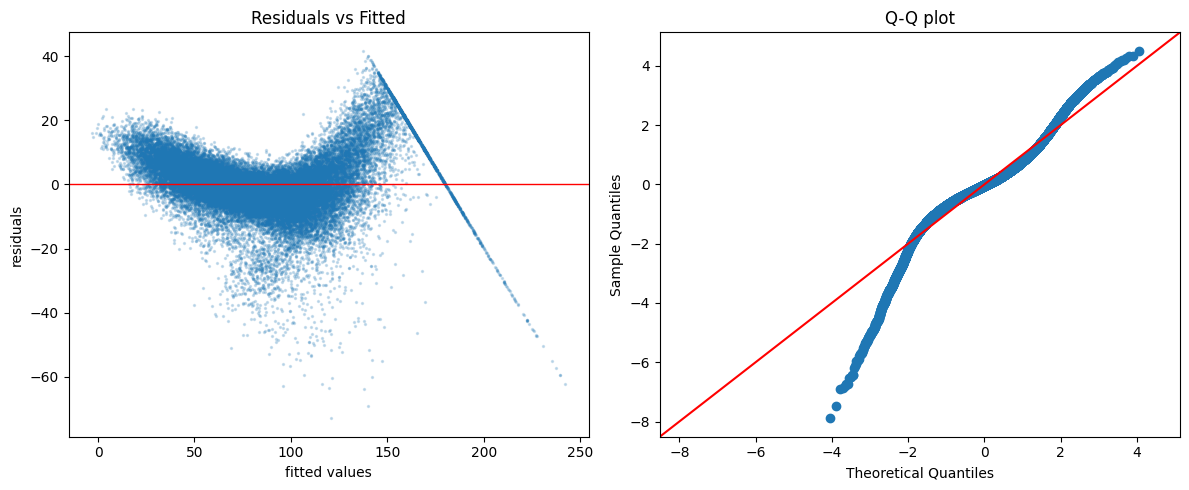

In [14]:
X_full = sm.add_constant(X_train.astype(float))
full_model = sm.OLS(y_train, X_full).fit()

import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# residuals vs fitted — looking for curvature or a cone
ax[0].scatter(full_model.fittedvalues, full_model.resid, s=2, alpha=0.2)
ax[0].axhline(0, color='red', lw=1)
ax[0].set_xlabel('fitted values'); ax[0].set_ylabel('residuals')
ax[0].set_title('Residuals vs Fitted')

# Q-Q — looking for departure from the line in the tails
sm.qqplot(full_model.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('Q-Q plot')

plt.tight_layout(); plt.show()

## Train Reduced Model

In [32]:
cols = [i - 1 for i in kept_idx if i != 0]      # drop the constant, shift for no-const X
red = LinearRegression().fit(X_train[:, cols], y_train)
y_pred_reduced = red.predict(X_test[:, cols])

In [37]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print(f"R2 Score: {r2_score(y_test, y_pred_reduced)}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_reduced)}")
print(f"y_test and y_pred adjusted_r2: {adjusted_r2(r2_score(y_test, y_pred_reduced),X_test.shape[0], 22)}")



R2 Score: 0.9303221351083588
RMSE: 9.341812462797318
y_test and y_pred adjusted_r2: 0.9301684904228205


## Reflection

### What two coefficients actually mean.

`Preparation_Time_Min = 0.974`, CI [0.929, 1.019]:  
>Every prep time minute more means one extra minute of  extra minute of delivery, kepping everything else constant.

---



`Vehicle_Type_Bike = - 67.19`, CI[-68.720,-65.661]:
>A delivery with a bike takes about 67 minutes less than  that same delivery on a bicycle keeping everything else  constant. The confidence interval is small and not zero >so we can trust this estimate.

### Full vs Reduced Model

Reflecting on the R2, RMSE, and adjusted R2 scores, the backward elimination process did not help the model's  predictive performance. The main reason being that the 21 dropped columns were dropped because their p-values said they contributed nothing. For example, the cuisine parameter provided nothing the prep time parameter didnt already provide. And because the predictors contributed nothing, removing them consequently changes the predictions by nothing. There was never any overfitting for elimination to fix.

### Part 8

This model taught me a valuable lesson: sometimes a model can score well on the metrics yet not provided valuable information. This was due to two main problems in the dataset. First *censoring*:  any target value over 180 was capped at 180, with 1,661 deliveries at exactly 180 minutes. Second *misspecification* two predictors were just ratios of each other:
>corr(Time,  Preparation_Time + 60 × Distance / Speed)  =  0.961

> Time − (Prep + 60 × Distance/Speed):   mean 3.49,  sd 11.43

These two factors ultimately broke the model. A fix would be to potentialy drop rows that have a target of 180, and feature engnieer the correlated features to be on column. However, dropping these columns would still negatively impact the model performance because we would not have all the rows that took a long delivry time and we would be loosing valuable information.